## Part 1: Data Visualization

## Part 1: Data Visualization

We first found the Titanic dataset from Kaggle, linked here: https://www.kaggle.com/competitions/titanic/overview. Seaborn has the titanic dataset built-in, so we decided to use that for convenience. Using the Seaborn dataset allows us to work with a unified dataset and perform our own train-test splits locally without needing to submit to Kaggle for every verification.

The dataset contains 891 rows of passenger data. We applied binary classification to predict passenger survival (1 for survived, 0 for deceased) based on demographic and travel-related features.

The Seaborn version of the dataset includes the following core features:
- `survived`: The target variable (0 = deceased, 1 = survived)
- `pclass`: Socioeconomic status (1st, 2nd, or 3rd class)
- `sex` and `age`: Basic demographic information
- `sibsp` and `parch`: Family size metrics (siblings/spouses and parents/children)
- `fare` and `embarked`: Trip details including the ticket price and port of departure
- `deck`: The passenger's deck (corresponding to the `Cabin` feature in the Kaggle version)

There are some missing values (N/A) for `age`, `embarked`, and `deck`. Part 2 covers how we decided to handle these missing values and encode the categorical data for our model.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None

--- Missing Values ---
survived         0
pclass    

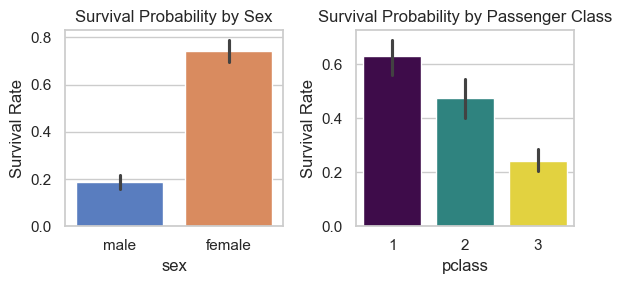

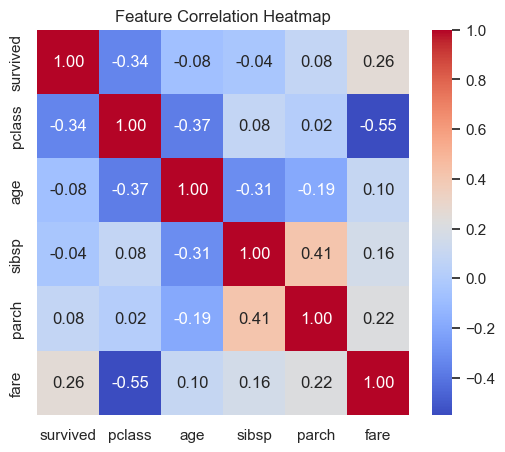

In [3]:
df = sns.load_dataset('titanic')

# Quick Data Inspection
print("--- Dataset Info ---")
print(df.info())
print("\n--- Missing Values ---")
print(df.isnull().sum())

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(6, 3))

# Survival by Sex
sns.barplot(x='sex', y='survived', data=df, ax=ax[0], palette='muted', hue='sex', legend=False)
ax[0].set_title('Survival Probability by Sex')
ax[0].set_ylabel('Survival Rate')

# Survival by Class
sns.barplot(x='pclass', y='survived', data=df, ax=ax[1], palette='viridis', hue='pclass', legend=False)
ax[1].set_title('Survival Probability by Passenger Class')
ax[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(6, 5))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

## Part 2: Data Cleaning

The titanic dataset contains missing values (N/A) for `Age`. We used the median age to "fill in" for any N/A data, since it is less likely to be skewed by outliers as compared to mean.


We also converted the categorical `sex` and `embarked` features into numerical values. For `sex`, we encoded female as 0, and male as 1. For `embarked`, we encoded S (Southampton) as 0, C (Cherbourg) as 1, Q (Queenstown) as 2.


Finally, we decided to drop column that were redundant or had a large percentage of missing values. The following table describes the features we decided to remove, and the reason why.
| Feature Removed | Redundant To | Reason for Removal |
| :--- | :--- | :--- |
| `alive` | `survived` | Binary indicator of the target variable. Removing prevents data leakage. |
| `who` | `sex` / `age` | Categorizes passengers as man, woman, or child. |
| `embark_town` | `embarked` | Full text name of the embarkation port. |
| `class` | `pclass` | Textual representation of the same thing (First, Second, Third). |
| `alone` | `sibsp` / `parch` | Boolean derived from family size metrics. |
| `deck` | N/A | Removed due to >75% missing values. |

In [4]:
# Fill missing Age with the Median
df['age'] = df['age'].fillna(df['age'].median())

# Fill missing Embarked with the mode
most_freq_port = df['embarked'].mode()[0]
df['embarked'] = df['embarked'].fillna(most_freq_port)

# Convert Categorical to Numeric
# # female=0, male=1
df['sex'] = df['sex'].map({'female': 0, 'male': 1}).astype(int)

# S=0, C=1, Q=2
df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2}).astype(int)

# Drop redundant or highly missing columns
drop_cols = ['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male', 'alone']
df = df.drop(drop_cols, axis=1)

print("--- Cleaning Complete ---")
print(df.head())
print("\nMissing values remaining:", df.isnull().sum().sum())

--- Cleaning Complete ---
   survived  pclass  sex   age  sibsp  parch     fare  embarked
0         0       3    1  22.0      1      0   7.2500         0
1         1       1    0  38.0      1      0  71.2833         1
2         1       3    0  26.0      0      0   7.9250         0
3         1       1    0  35.0      1      0  53.1000         0
4         0       3    1  35.0      0      0   8.0500         0

Missing values remaining: 0


## Part 3: Support Vector Machines

After cleaning the dataset, we used SVM to predict whether a passenger survived or not. To study the effect of feature selection, we compared 2 feature sets:
- **Basic** that includes core passenger information: `pclass`, `sex`, `age`, `fare`, and `embarked`.
- **With Family** added `sibsp` and `parch` to include family-related information.


For each feature set, we trained 3 SVM kernels:
- linear
- rbf
- poly

Because SVM is sensitive to feature scale, we standardized the predictors before training using `StandardScaler`. We then computed model accuracy across all combinations of feature set and kernel.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd


feature_sets = {
    "Basic": ['pclass', 'sex', 'age', 'fare', 'embarked'],
    "With Family": ['pclass', 'sex', 'age', 'fare', 'embarked', 'sibsp', 'parch'],
}

results = []

for feature_set_name, feature_cols in feature_sets.items():
    X = df[feature_cols]
    y = df['survived']
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Try multiple SVM kernels
    for kernel in ['linear', 'rbf', 'poly']:
        svm_model = SVC(kernel=kernel)
        svm_model.fit(X_train_scaled, y_train)
        
        y_pred = svm_model.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        
        results.append({
            'Feature Set': feature_set_name,
            'Kernel': kernel,
            'Accuracy': acc
        })
        
        print(f"\nFeature Set: {feature_set_name}")
        print(f"Kernel: {kernel}")
        print(f"Accuracy: {acc:.4f}")



Feature Set: Basic
Kernel: linear
Accuracy: 0.7765

Feature Set: Basic
Kernel: rbf
Accuracy: 0.8101

Feature Set: Basic
Kernel: poly
Accuracy: 0.7989

Feature Set: With Family
Kernel: linear
Accuracy: 0.7765

Feature Set: With Family
Kernel: rbf
Accuracy: 0.8156

Feature Set: With Family
Kernel: poly
Accuracy: 0.7989


In [6]:
# Display the results in a table
results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
print("\n SVM Results")
print(results_df)


 SVM Results
   Feature Set  Kernel  Accuracy
4  With Family     rbf  0.815642
1        Basic     rbf  0.810056
2        Basic    poly  0.798883
5  With Family    poly  0.798883
0        Basic  linear  0.776536
3  With Family  linear  0.776536


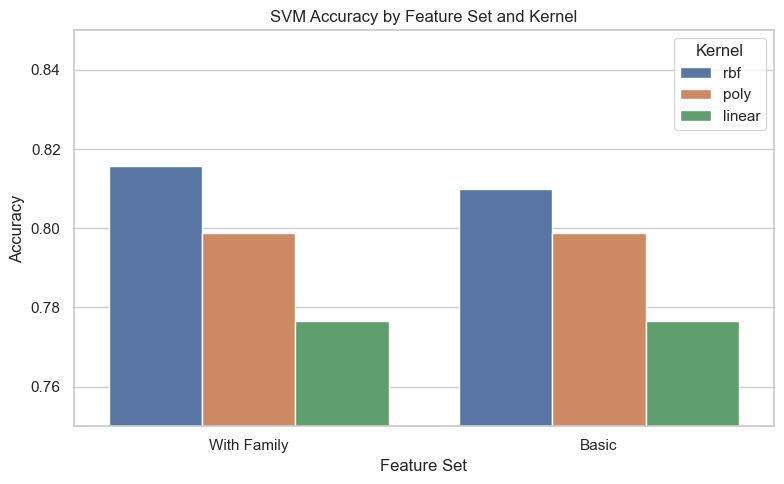

In [7]:
# A bar chat to visualize accuracy by feature set and kernel
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x='Feature Set', y='Accuracy', hue='Kernel')
plt.title('SVM Accuracy by Feature Set and Kernel')
plt.ylim(0.75, 0.85)
plt.ylabel('Accuracy')
plt.xlabel('Feature Set')
plt.tight_layout()
plt.show()

After comparing the models, the **RBF kernel with the With Family feature set** performed better than the other models. This suggests that the `sibsp` and `parch` added some predictive value.

After selecting the RBF kernel, we tuned its hyperparameters using cross-validation to give a more optimized model in the final SVM setup

In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

Best Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.8287107258938246
